We loaded the source data for each country from the file co2-emissions-and-gdp.csv. For an initial overview, we display the first few rows

In [53]:
import pandas as pd

gdpco2 = pd.read_csv("co2-emissions-and-gdp.csv")
print(gdpco2.head())

        Entity Code  Year  \
0  Afghanistan  AFG  1990   
1  Afghanistan  AFG  1991   
2  Afghanistan  AFG  1992   
3  Afghanistan  AFG  1993   
4  Afghanistan  AFG  1994   

   GDP per capita, PPP (constant 2011 international $)  \
0                                                NaN     
1                                                NaN     
2                                                NaN     
3                                                NaN     
4                                                NaN     

   Per capita consumption-based CO2 emissions  Per capita CO2 emissions  
0                                         NaN                  0.209736  
1                                         NaN                  0.182522  
2                                         NaN                  0.095227  
3                                         NaN                  0.084280  
4                                         NaN                  0.075053  


We filtered out only the necessary countries, deleted the column with regular CO₂ emissions (we use consumption-adjusted emissions), and renamed the columns for further work

In [ ]:
countries = ["Sweden", "United Kingdom", "France", "United States", "Germany", "Denmark"]

# Filtering by country
gdpco2_six = gdpco2[gdpco2["Entity"].isin(countries)].copy()

# Deleting an extra column
gdpco2_six = gdpco2_six.drop(columns=["Per capita CO2 emissions"])

# Renaming columns for convenience
gdpco2_six = gdpco2_six.rename(columns={
    "Per capita consumption-based CO2 emissions": "Emissions",
    "GDP per capita, PPP (constant 2011 international $)": "GDP"
})

print(gdpco2_six.head())

       Entity Code  Year           GDP  Emissions
1733  Denmark  DNK  1990  33785.650143  11.983610
1734  Denmark  DNK  1991  34167.719280  12.671095
1735  Denmark  DNK  1992  34721.381781  13.284371
1736  Denmark  DNK  1993  34609.583085  12.810058
1737  Denmark  DNK  1994  36332.217340  13.105980


An index was calculated for each time series: values for 1990 are taken as 100, with the rest proportional to them

In [ ]:
# Highlighting the values for 1990
gdpco2_90 = gdpco2_six[gdpco2_six["Year"] == 1990][["Entity", "Emissions", "GDP"]].copy()
gdpco2_90 = gdpco2_90.rename(columns={"Emissions": "Emissions_90", "GDP": "GDP_90"})

# Combine with the main dataset for the country
gdpco2_six_index = pd.merge(gdpco2_six, gdpco2_90, on="Entity")

# Calculating indices
gdpco2_six_index["Emissions_index"] = gdpco2_six_index["Emissions"] / gdpco2_six_index["Emissions_90"] * 100
gdpco2_six_index["GDP_index"] = gdpco2_six_index["GDP"] / gdpco2_six_index["GDP_90"] * 100

print(gdpco2_six_index.head())

    Entity Code  Year           GDP  Emissions  Emissions_90        GDP_90  \
0  Denmark  DNK  1990  33785.650143  11.983610      11.98361  33785.650143   
1  Denmark  DNK  1991  34167.719280  12.671095      11.98361  33785.650143   
2  Denmark  DNK  1992  34721.381781  13.284371      11.98361  33785.650143   
3  Denmark  DNK  1993  34609.583085  12.810058      11.98361  33785.650143   
4  Denmark  DNK  1994  36332.217340  13.105980      11.98361  33785.650143   

   Emissions_index   GDP_index  
0       100.000000  100.000000  
1       105.736877  101.130862  
2       110.854500  102.769613  
3       106.896486  102.438707  
4       109.365876  107.537423  


Prepared data for graphing: converted from a wide format (separate columns for each index) to a long format, where each country, year, and index type has its own value

In [ ]:
# Select the required columns
gdpco2_plot = gdpco2_six_index[["Entity", "Year", "Emissions_index", "GDP_index"]].copy()

# Convert to long format
gdpco2_plot_long = pd.melt(
    gdpco2_plot,
    id_vars=["Entity", "Year"],
    value_vars=["Emissions_index", "GDP_index"],
    var_name="Index",
    value_name="Value"
)

print(gdpco2_plot_long.head())

    Entity  Year            Index       Value
0  Denmark  1990  Emissions_index  100.000000
1  Denmark  1991  Emissions_index  105.736877
2  Denmark  1992  Emissions_index  110.854500
3  Denmark  1993  Emissions_index  106.896486
4  Denmark  1994  Emissions_index  109.365876


We constructed a basic graph for Sweden: lines and points for each index (GDP and CO₂)

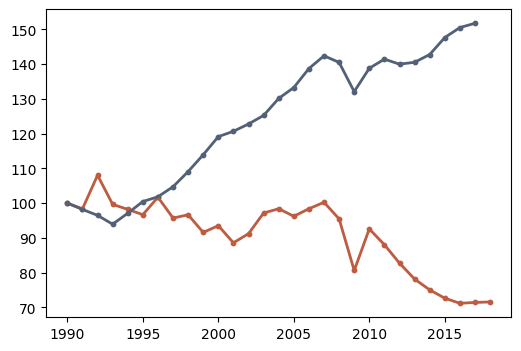

In [ ]:
import matplotlib.pyplot as plt

sweden_data = gdpco2_plot_long[gdpco2_plot_long["Entity"] == "Sweden"]

color_dict = {"GDP_index": "#526177", "Emissions_index": "#BE5B40"}

plt.figure(figsize=(6, 4))

# Constructing lines and points for each index
for idx, group in sweden_data.groupby("Index"):
    plt.plot(group["Year"], group["Value"], color=color_dict[idx], label=idx, linewidth=2)
    plt.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

plt.show()

removed captions and grid, increased the font size for the X-axis, removed the Y-axis, set a custom background colour, and added a frame

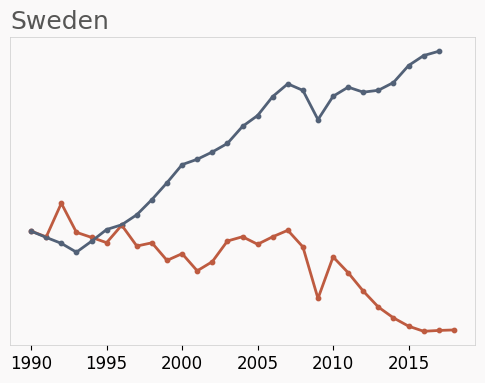

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for idx, group in sweden_data.groupby("Index"):
    ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
    ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

# Design
ax.set_title("Sweden", fontsize=18, color="#565655", loc="left")
ax.set_facecolor("#FAF9F9")
fig.patch.set_facecolor("#FAF9F9")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
    spine.set_linewidth(0.5)
ax.grid(False)
ax.set_xlabel("")  # axis.title
ax.set_ylabel("")  # axis.title
ax.tick_params(axis='y', left=False, labelleft=False)  # axis.text.y
ax.tick_params(axis='x', labelsize=12)

plt.show()

The X-axis is limited to the range 1990–2024, with labels only for the extreme years

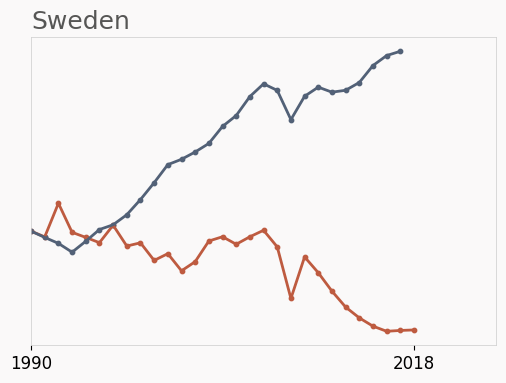

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

for idx, group in sweden_data.groupby("Index"):
    ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
    ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

# Design
ax.set_title("Sweden", fontsize=18, color="#565655", loc="left")
ax.set_facecolor("#FAF9F9")
fig.patch.set_facecolor("#FAF9F9")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
    spine.set_linewidth(0.5)
ax.grid(False)
ax.set_xlabel("")  # axis.title
ax.set_ylabel("")  # axis.title
ax.tick_params(axis='y', left=False, labelleft=False)  # axis.text.y
ax.tick_params(axis='x', labelsize=12)

ax.set_xticks([1990, 2018])
ax.set_xlim(1990, 2024)

plt.show()

Filtered the latest GDP (2017) and Emissions (2018) values for each country. Created a Label column with the percentage change relative to 1990, adding a ‘+’ sign for positive changes

In [ ]:
# Filter the latest values for GDP and Emissions
datalabels = gdpco2_plot_long[
    ((gdpco2_plot_long["Year"] == 2017) & (gdpco2_plot_long["Index"] == "GDP_index")) |
    ((gdpco2_plot_long["Year"] == 2018) & (gdpco2_plot_long["Index"] == "Emissions_index"))
].copy()

# Create a column with labels for percentages
def format_label(value):
    delta = round(value - 100)
    sign = "+" if delta > 0 else ""
    return f"{sign}{delta}%"

datalabels["Label"] = datalabels["Value"].apply(format_label)

print(datalabels)

             Entity  Year            Index       Value Label
28          Denmark  2018  Emissions_index   74.593123  -25%
58           France  2018  Emissions_index   77.386910  -23%
88          Germany  2018  Emissions_index   68.799877  -31%
118          Sweden  2018  Emissions_index   71.553181  -28%
148  United Kingdom  2018  Emissions_index   68.711264  -31%
178   United States  2018  Emissions_index   88.113038  -12%
207         Denmark  2017        GDP_index  138.172610  +38%
237          France  2017        GDP_index  130.800820  +31%
267         Germany  2017        GDP_index  144.562100  +45%
297          Sweden  2017        GDP_index  151.774231  +52%
327  United Kingdom  2017        GDP_index  148.179058  +48%
357   United States  2017        GDP_index  146.309577  +46%


Added text labels with the percentage change for each line (GDP and Emissions) for Sweden on the right side of the graph. The colour of the label corresponds to the colour of the line.

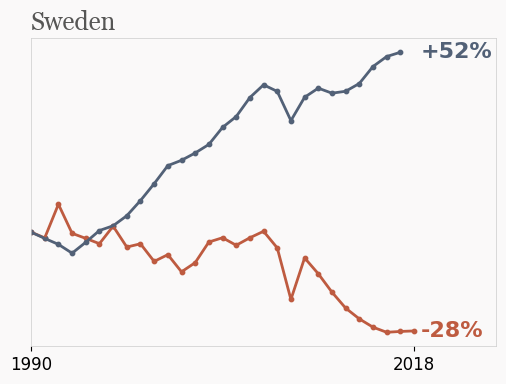

In [ ]:
# Filtering tags for Sweden
sweden_labels = datalabels[datalabels["Entity"] == "Sweden"]

fig, ax = plt.subplots(figsize=(6, 4))

# Building lines and points
for idx, group in sweden_data.groupby("Index"):
    ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
    ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

# Add labels with percentages
for i, row in sweden_labels.iterrows():
    ax.text(
        2018.5, row["Value"], row["Label"],
        color=color_dict[row["Index"]],
        fontsize=16, fontweight="bold", va="center", ha="left"
    )

# Stylise the graph
ax.set_title("Sweden", fontsize=18, color="#565655", loc="left", fontname="Georgia")
ax.set_facecolor("#FAF9F9")
fig.patch.set_facecolor("#FAF9F9")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
    spine.set_linewidth(0.5)
ax.grid(False)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_xticks([1990, 2018])
ax.set_xlim(1990, 2024)
ax.tick_params(axis='x', labelsize=12)

plt.show()

Added text annotations

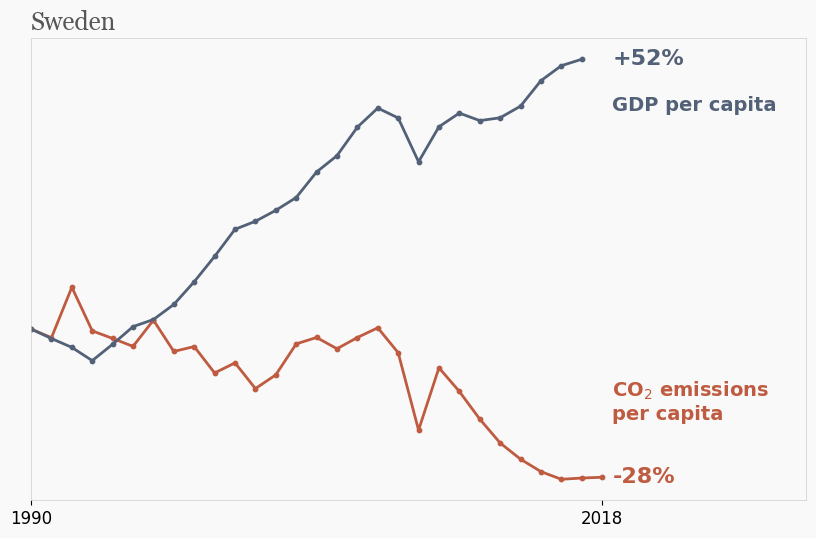

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# Lines and points
for idx, group in sweden_data.groupby("Index"):
    ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
    ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

# Percentages
for i, row in sweden_labels.iterrows():
    ax.text(
        2018.5, row["Value"], row["Label"],
        color=color_dict[row["Index"]],
        fontsize=16, fontweight="bold", va="center", ha="left"
    )

# Annotated labels
ax.text(
    2018.5, 143, "GDP per capita",
    color="#526177", fontsize=14, ha="left", va="center", fontweight="bold"
)
ax.text(
    2018.5, 86, "CO$_2$ emissions\nper capita",
    color="#BE5B40", fontsize=14, ha="left", va="center", fontweight="bold"
)

# Other formatting (font, background, frame)
ax.set_title("Sweden", fontsize=18, color="#565655", loc="left", fontname="Georgia")
ax.set_facecolor("#FAF9F9")
fig.patch.set_facecolor("#FAF9F9")
for spine in ax.spines.values():
    spine.set_edgecolor("#CCCCCC")
    spine.set_linewidth(0.5)
ax.grid(False)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis='y', left=False, labelleft=False)
ax.set_xticks([1990, 2018])
ax.set_xlim(1990, 2028)
ax.tick_params(axis='x', labelsize=12)

plt.show()

First, we create a function that builds ONE graph for a country with annotations, percentage labels, background colour, and formatted captions

In [ ]:
def plot_country(ax, country, data, labels, color_dict):
    # Data filtering
    country_data = data[data["Entity"] == country]
    country_labels = labels[labels["Entity"] == country]

    # Lines and points
    for idx, group in country_data.groupby("Index"):
        ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
        ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)

    # Percentages
    for i, row in country_labels.iterrows():
        ax.text(
            2018.5, row["Value"], row["Label"],
            color=color_dict[row["Index"]],
            fontsize=16, fontweight="bold", va="center", ha="left"
        )

    # Annotated labels, Y-positions are adjusted individuall
    if country == "Sweden":
        ax.text(2018.5, 143, "GDP per capita", color="#526177", fontsize=14, ha="left", va="center", fontweight="bold")
        ax.text(2018.5, 86, "CO$_2$ emissions\nper capita", color="#BE5B40", fontsize=14, ha="left", va="center", fontweight="bold")
    # For other countries, the Y values for annotations are selected by analogy

    # Design
    ax.set_title(country, fontsize=18, color="#565655", loc="left", fontname="Georgia")
    ax.set_facecolor("#FAF9F9")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
        spine.set_linewidth(0.5)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.set_xticks([1990, 2018])
    ax.set_xlim(1990, 2028)
    ax.tick_params(axis='x', labelsize=12)

Creating a 2×3 ‘patchwork’ mosaic with indents

Text(0.5, 0.04, 'Other countries achieved the same. Data for more countries can be found on OurWorldinData.org')

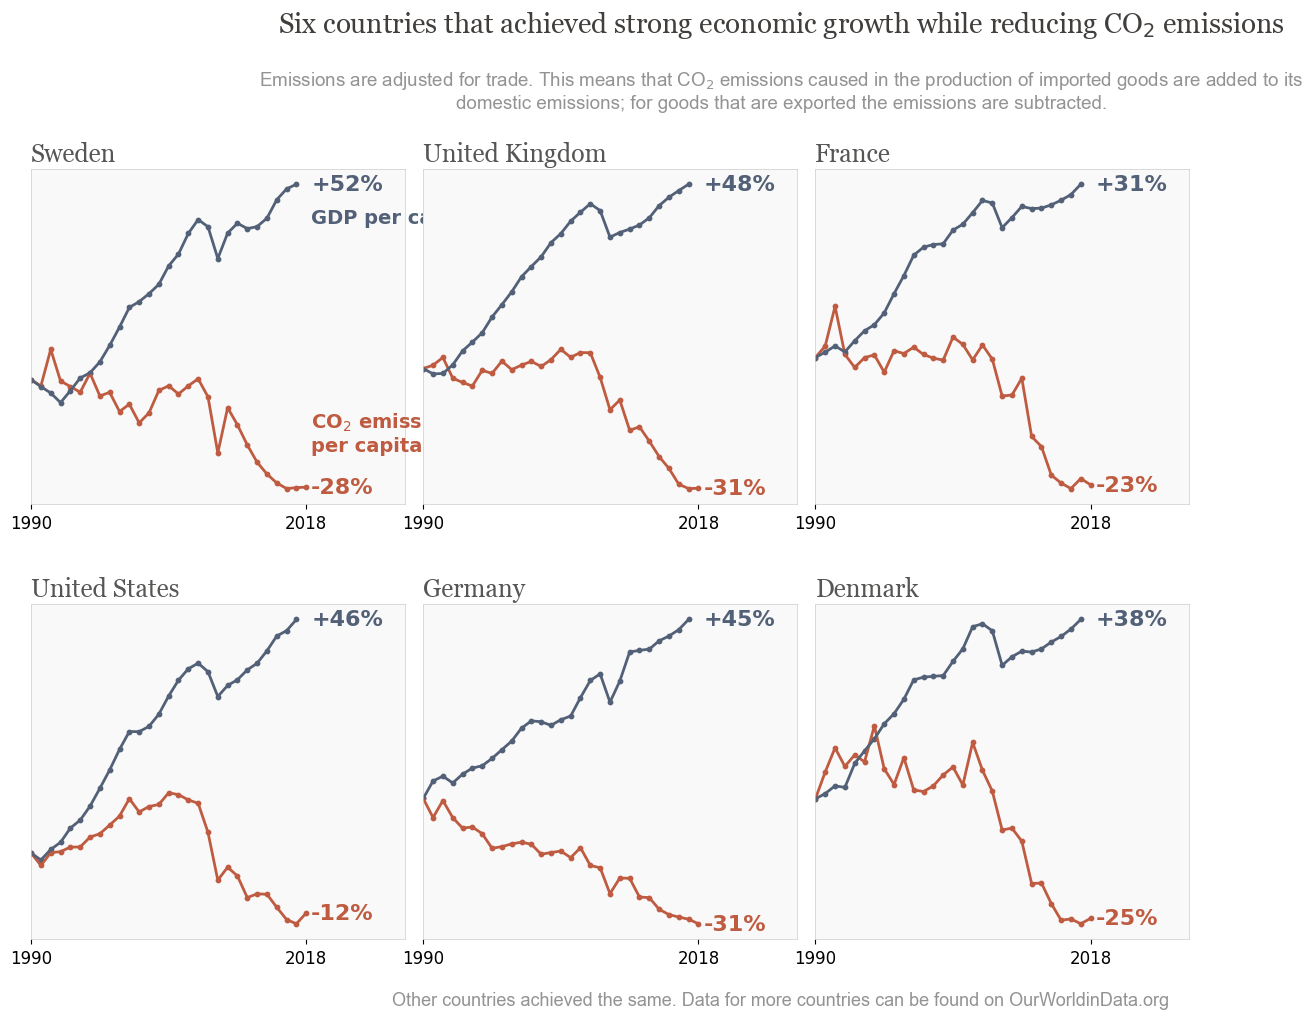

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

countries = ["Sweden", "United Kingdom", "France", "United States", "Germany", "Denmark"]
color_dict = {"GDP_index": "#526177", "Emissions_index": "#BE5B40"}

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(nrows=2, ncols=7, width_ratios=[1,0.05,1,0.05,1,0.05,1], height_ratios=[1,1])

# First row
axes = []
axes.append(fig.add_subplot(gs[0,0])) # Sweden
axes.append(fig.add_subplot(gs[0,2])) # UK
axes.append(fig.add_subplot(gs[0,4])) # France

# Second row
axes.append(fig.add_subplot(gs[1,0])) # US
axes.append(fig.add_subplot(gs[1,2])) # Germany
axes.append(fig.add_subplot(gs[1,4])) # Denmark

for ax, country in zip(axes, countries):
    plot_country(ax, country, gdpco2_plot_long, datalabels, color_dict)

# Disable empty subplots
for pos in [1,3,5]:
    fig.add_subplot(gs[0,pos]).axis('off')
    fig.add_subplot(gs[1,pos]).axis('off')

# Line spacing
fig.subplots_adjust(hspace=0.3, wspace=0)
fig.suptitle(
    "Six countries that achieved strong economic growth while reducing CO$_2$ emissions",
    fontsize=20, color="#413E3C", fontname="Georgia", y=1.04
)
fig.text(
    0.5, 0.98,
    "Emissions are adjusted for trade. This means that CO$_2$ emissions caused in the production of imported goods are added to its\n"
    "domestic emissions; for goods that are exported the emissions are subtracted.",
    ha='center', va='top', fontsize=13.5, color="#949393", fontname="Arial"
)
fig.text(
    0.5, 0.04,
    "Other countries achieved the same. Data for more countries can be found on OurWorldinData.org",
    ha='center', va='bottom', fontsize=13, color="#949393", fontname="Arial"
)

Full script with corrected layout

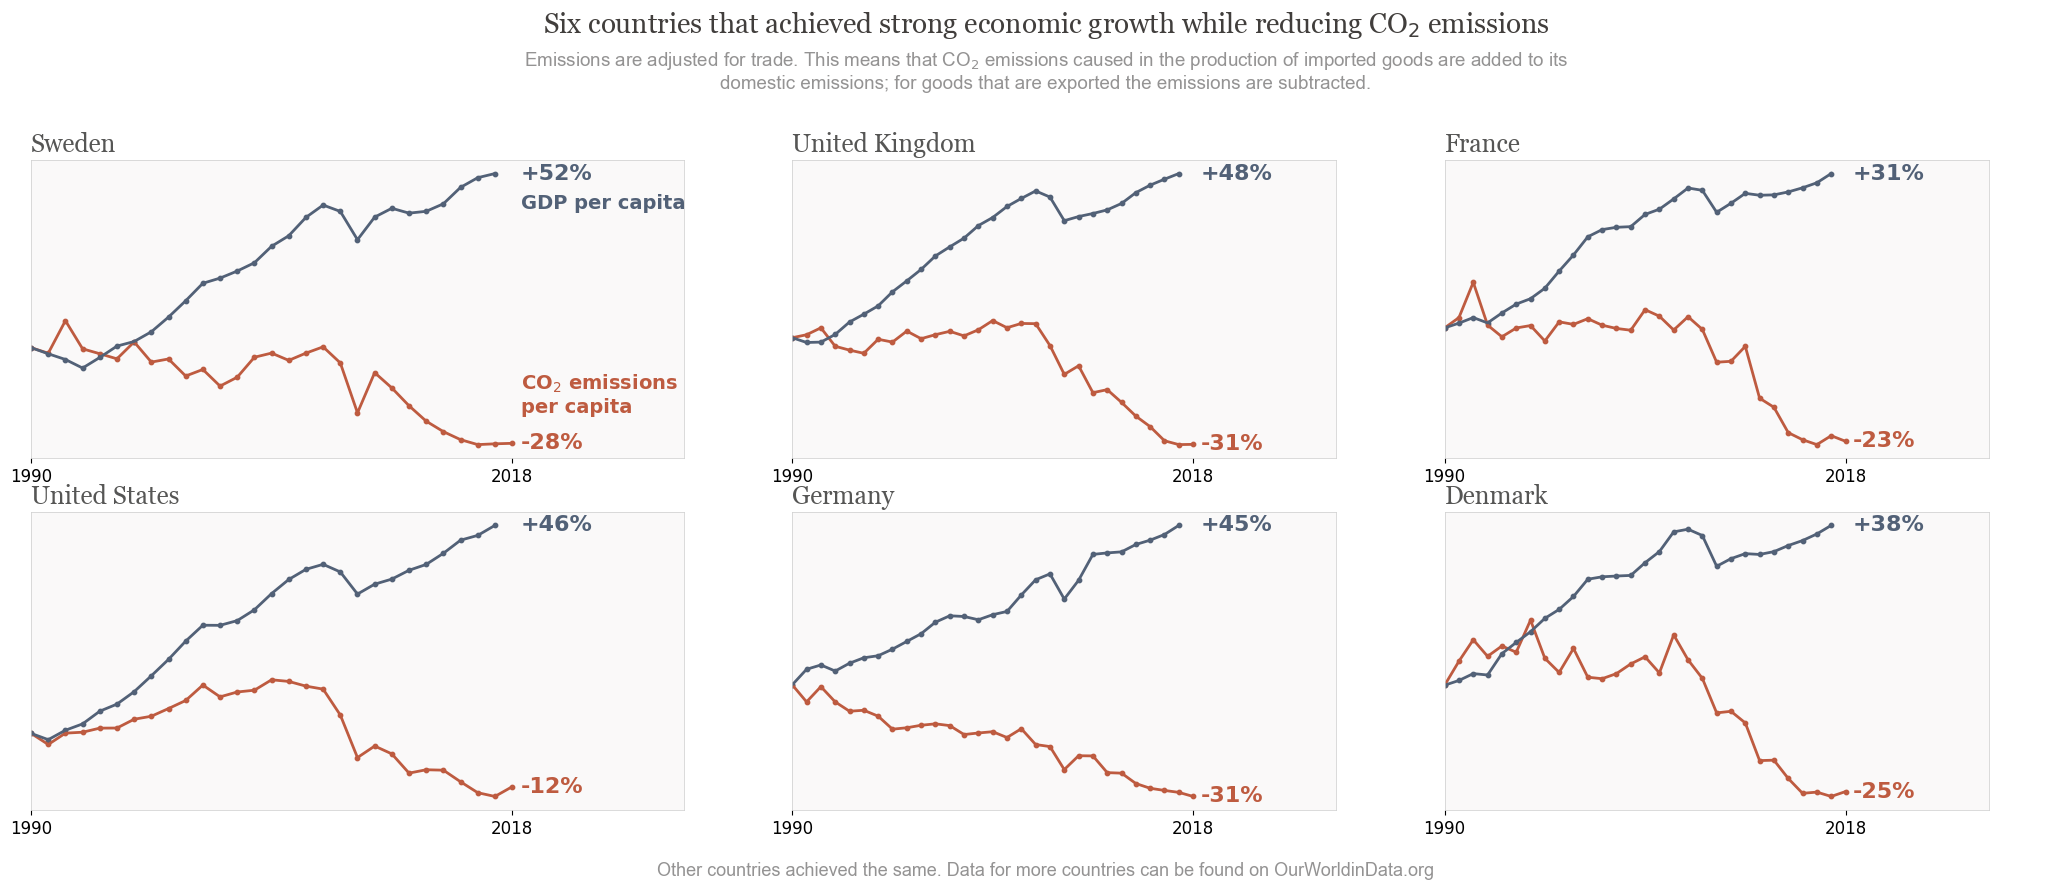

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==== 1. Set data ====
gdpco2 = pd.read_csv("co2-emissions-and-gdp.csv")

# ==== 2. Prepare data ====
countries = ["Sweden", "United Kingdom", "France", "United States", "Germany", "Denmark"]

# Filtering countries, deleting unnecessary columns, renaming
gdpco2_six = gdpco2[gdpco2["Entity"].isin(countries)].copy()
gdpco2_six = gdpco2_six.drop(columns=["Per capita CO2 emissions"])
gdpco2_six = gdpco2_six.rename(columns={
    "Per capita consumption-based CO2 emissions": "Emissions",
    "GDP per capita, PPP (constant 2011 international $)": "GDP"
})

# ==== 3. Indexation based on 1990 ====
gdpco2_90 = gdpco2_six[gdpco2_six["Year"] == 1990][["Entity", "Emissions", "GDP"]].copy()
gdpco2_90 = gdpco2_90.rename(columns={"Emissions": "Emissions_90", "GDP": "GDP_90"})
gdpco2_six_index = pd.merge(gdpco2_six, gdpco2_90, on="Entity")
gdpco2_six_index["Emissions_index"] = gdpco2_six_index["Emissions"] / gdpco2_six_index["Emissions_90"] * 100
gdpco2_six_index["GDP_index"] = gdpco2_six_index["GDP"] / gdpco2_six_index["GDP_90"] * 100

# ==== 4. Long format for visualisation ====
gdpco2_plot = gdpco2_six_index[["Entity", "Year", "Emissions_index", "GDP_index"]].copy()
gdpco2_plot_long = pd.melt(
    gdpco2_plot,
    id_vars=["Entity", "Year"],
    value_vars=["Emissions_index", "GDP_index"],
    var_name="Index",
    value_name="Value"
)

# ==== 5. Creating labels for percentages ====
datalabels = gdpco2_plot_long[
    ((gdpco2_plot_long["Year"] == 2017) & (gdpco2_plot_long["Index"] == "GDP_index")) |
    ((gdpco2_plot_long["Year"] == 2018) & (gdpco2_plot_long["Index"] == "Emissions_index"))
].copy()

def format_label(value):
    delta = round(value - 100)
    sign = "+" if delta > 0 else ""
    return f"{sign}{delta}%"

datalabels["Label"] = datalabels["Value"].apply(format_label)

# ==== 6. Function for the base chart of a single country ====
def plot_country(ax, country, data, labels, color_dict):
    country_data = data[data["Entity"] == country]
    country_labels = labels[labels["Entity"] == country]
    # Lines and points
    for idx, group in country_data.groupby("Index"):
        ax.plot(group["Year"], group["Value"], color=color_dict[idx], linewidth=2)
        ax.scatter(group["Year"], group["Value"], color=color_dict[idx], s=10)
    # Percentage labels
    for i, row in country_labels.iterrows():
        ax.text(
            2018.5, row["Value"], row["Label"],
            color=color_dict[row["Index"]],
            fontsize=16, fontweight="bold", va="center", ha="left"
        )
    # Annotated labels, Y-positions are adjusted individually
    if country == "Sweden":
        ax.text(2018.5, 143, "GDP per capita", color="#526177", fontsize=14, ha="left", va="center", fontweight="bold")
        ax.text(2018.5, 86, "CO$_2$ emissions\nper capita", color="#BE5B40", fontsize=14, ha="left", va="center", fontweight="bold")
    # Formatting
    ax.set_title(country, fontsize=18, color="#565655", loc="left", fontname="Georgia")
    ax.set_facecolor("#FAF9F9")
    for spine in ax.spines.values():
        spine.set_edgecolor("#CCCCCC")
        spine.set_linewidth(0.5)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='y', left=False, labelleft=False)
    ax.set_xticks([1990, 2018])
    ax.set_xlim(1990, 2028)
    ax.tick_params(axis='x', labelsize=12)

# ==== 7. Building the "patchwork" mosaic ====
color_dict = {"GDP_index": "#526177", "Emissions_index": "#BE5B40"}
fig = plt.figure(figsize=(29, 10))
gs = gridspec.GridSpec(nrows=2, ncols=7, width_ratios=[1.2,0.05,1,0.05,1,0.05,1], height_ratios=[1,1])

axes = []
axes.append(fig.add_subplot(gs[0,0])) # Sweden
axes.append(fig.add_subplot(gs[0,2])) # UK
axes.append(fig.add_subplot(gs[0,4])) # France
axes.append(fig.add_subplot(gs[1,0])) # US
axes.append(fig.add_subplot(gs[1,2])) # Germany
axes.append(fig.add_subplot(gs[1,4])) # Denmark

for ax, country in zip(axes, countries):
    plot_country(ax, country, gdpco2_plot_long, datalabels, color_dict)

# Disable empty subplots
for pos in [1,3,5]:
    fig.add_subplot(gs[0,pos]).axis('off')
    fig.add_subplot(gs[1,pos]).axis('off')

fig.subplots_adjust(hspace=0.3, wspace=0, top=0.82, bottom=0.15)

# ==== 8. Title, subtitle, caption ====
fig.suptitle(
    "Six countries that achieved strong economic growth while reducing CO$_2$ emissions",
    fontsize=20, color="#413E3C", fontname="Georgia", y=0.95, x=0.4
)

fig.text(
    0.4, 0.91,
    "Emissions are adjusted for trade. This means that CO$_2$ emissions caused in the production of imported goods are added to its\n"
    "domestic emissions; for goods that are exported the emissions are subtracted.",
    ha='center', va='top', fontsize=13.5, color="#949393", fontname="Arial"
)

fig.text(
    0.4, 0.08,
    "Other countries achieved the same. Data for more countries can be found on OurWorldinData.org",
    ha='center', va='bottom', fontsize=13, color="#949393", fontname="Arial"
)
plt.subplots_adjust(left=0.05, right=0.95, top=0.8, bottom=0.15, wspace=0.12, hspace=0.18)

# ==== 9. Export image ====
plt.savefig("patchwork_gdp_co2.png", dpi=300)
plt.show()

The final image is large in size (the right side is empty). I did this to solve the layout curve issues, but it didn't turn out perfectly clean. Ultimately, if you use this image, you can simply crop it.